In [1]:
import joblib
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

MODEL_PATH = (
    "RandomForest_PlattCalibrated.joblib"
)

model = joblib.load(MODEL_PATH)


In [2]:
def compute_morgan_count(mol, n_bits=2048):
    fp = rdMolDescriptors.GetHashedMorganFingerprint(
        mol,
        radius=2,
        nBits=n_bits
    )

    arr = np.zeros((n_bits,), dtype=int)
    for idx, value in fp.GetNonzeroElements().items():
        arr[idx] = value

    return arr

In [3]:
def load_pubchem_morgan(pubchem_csv):
    df = pd.read_csv(pubchem_csv)

    X, y, ids = [], [], []

    for idx, row in df.iterrows():
        mol = Chem.MolFromSmiles(row["standard_smiles"])
        if mol is None:
            continue

        X.append(compute_morgan_count(mol))
        y.append(row["class"])
        ids.append(f"PUBCHEM_{idx}")

    return np.array(X), np.array(y), ids



In [32]:
X_pubchem, y_pubchem, pubchem_ids = load_pubchem_morgan("ache_test_human_clean.csv")


y_prob = model.predict_proba(X_pubchem)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)


In [33]:
import numpy as np
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    brier_score_loss,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    confusion_matrix
)

print("External PubChem Evaluation (ChEMBL-trained model)")
print("--------------------------------------------------")

# Ranking metrics (require both classes)
if len(np.unique(y_pubchem)) > 1:
    print("ROC-AUC :", roc_auc_score(y_pubchem, y_prob))
    print("PR-AUC  :", average_precision_score(y_pubchem, y_prob))
else:
    print("ROC-AUC : undefined (single class)")
    print("PR-AUC  : undefined (single class)")

# Threshold-based metrics
print("Accuracy :", accuracy_score(y_pubchem, y_pred))
print("Precision:", precision_score(y_pubchem, y_pred, zero_division=0))
print("Recall   :", recall_score(y_pubchem, y_pred, zero_division=0))
print("F1-score :", f1_score(y_pubchem, y_pred, zero_division=0))
print("MCC      :", matthews_corrcoef(y_pubchem, y_pred))
print("Brier    :", brier_score_loss(y_pubchem, y_prob))

# Cohen's Kappa
print("Kappa    :", cohen_kappa_score(y_pubchem, y_pred))

# Specificity (True Negative Rate)
tn, fp, fn, tp = confusion_matrix(y_pubchem, y_pred).ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
print("Specificity:", specificity)


# Expected Calibration Error (ECE)
def compute_ece(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    binids = np.digitize(y_prob, bins) - 1
    
    ece = 0.0
    for i in range(n_bins):
        mask = binids == i
        if np.any(mask):
            bin_acc = np.mean(y_true[mask])
            bin_conf = np.mean(y_prob[mask])
            ece += np.abs(bin_acc - bin_conf) * np.sum(mask) / len(y_true)
    return ece

ece = compute_ece(y_pubchem, y_prob, n_bins=10)
print("ECE      :", ece)

External PubChem Evaluation (ChEMBL-trained model)
--------------------------------------------------
ROC-AUC : 0.8115942028985508
PR-AUC  : 0.7757325795037591
Accuracy : 0.7087378640776699
Precision: 0.5428571428571428
Recall   : 0.8260869565217391
F1-score : 0.6551724137931034
MCC      : 0.4491410212962799
Brier    : 0.21906351695101636
Kappa    : 0.4211857263276202
Specificity: 0.6496350364963503
ECE      : 0.26151056398593225


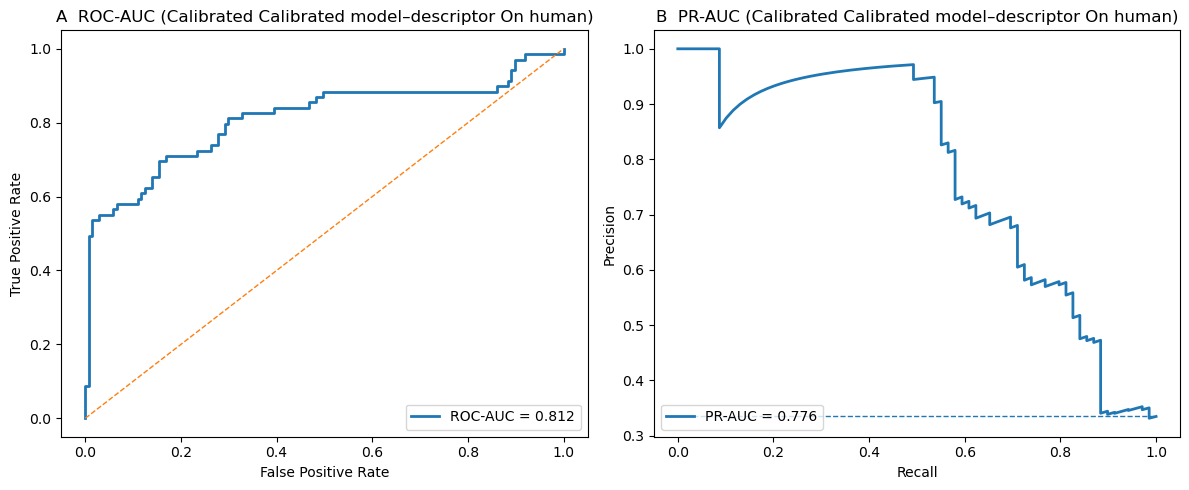

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score
)

# =========================
# Compute curves
# =========================
fpr, tpr, _ = roc_curve(y_pubchem, y_prob)
precision, recall, _ = precision_recall_curve(y_pubchem, y_prob)

roc_auc = roc_auc_score(y_pubchem, y_prob)
pr_auc = average_precision_score(y_pubchem, y_prob)

baseline = np.mean(y_pubchem)

# =========================
# Create side-by-side figure
# =========================
plt.figure(figsize=(12, 5))

# -------- Panel A: ROC --------
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, linewidth=2, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("A  ROC-AUC (Calibrated Calibrated model–descriptor On human)")
plt.legend(loc="lower right")

# -------- Panel B: PR --------
plt.subplot(1, 2, 2)
plt.plot(recall, precision, linewidth=2, label=f"PR-AUC = {pr_auc:.3f}")
plt.hlines(baseline, 0, 1, linestyle="--", linewidth=1)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("B  PR-AUC (Calibrated Calibrated model–descriptor On human)")
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()



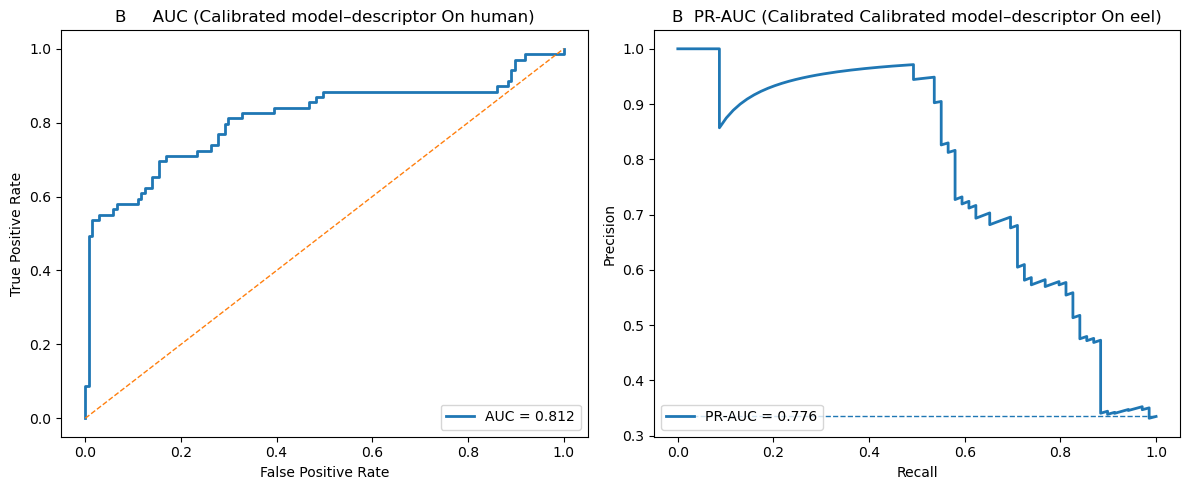

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score
)

# =========================
# Compute curves
# =========================
fpr, tpr, _ = roc_curve(y_pubchem, y_prob)
precision, recall, _ = precision_recall_curve(y_pubchem, y_prob)

roc_auc = roc_auc_score(y_pubchem, y_prob)
pr_auc = average_precision_score(y_pubchem, y_prob)

baseline = np.mean(y_pubchem)

# =========================
# Create side-by-side figure
# =========================
plt.figure(figsize=(12, 5))

# -------- Panel A: ROC --------
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("B     AUC (Calibrated model–descriptor On human)")
plt.legend(loc="lower right")

# -------- Panel B: PR --------
plt.subplot(1, 2, 2)
plt.plot(recall, precision, linewidth=2, label=f"PR-AUC = {pr_auc:.3f}")
plt.hlines(baseline, 0, 1, linestyle="--", linewidth=1)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("B  PR-AUC (Calibrated Calibrated model–descriptor On eel)")
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

